# Week 8

Purpose is to clearly display models and results. 

Trougout the notebook, we are modelling 4 states. 
The states are listed in order of increasing the CO2 concentration. 


1. The windows is opened and no persons are present.
2. The windows is opened and persons are present.
3. The windows is closed and no persons are present.
4. The windows is closed and persons are present. 

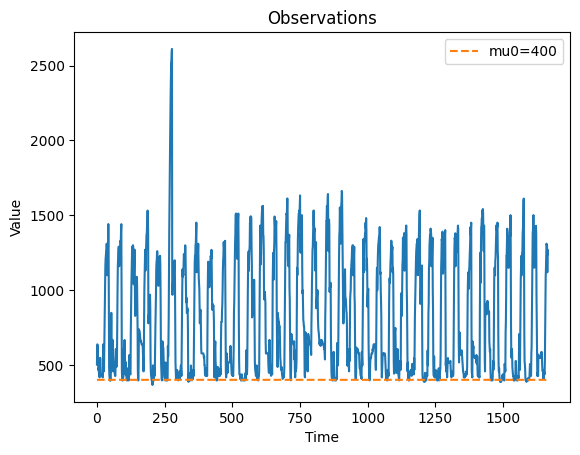

In [1]:
from src.api.v4.utils import load_y_data
from src.api.v4.transitions.static_transition_higher_order import decode_possible_transitions 
from src.data import load_and_aggregate_data
import matplotlib.pyplot as plt 
import jax.numpy as jnp
import jax 
jax.config.update("jax_enable_x64", True)

ys = load_y_data() 
data = load_and_aggregate_data()
HOURS_TO_PLOT = 24
results = {}



plt.plot(ys)
plt.plot(jnp.ones_like(ys) * 400, "--", label="mu0=400")
plt.title("Observations")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.show()

In [2]:
hour = jnp.asarray(data["Hour"].values) 

# Model fits and summary

In [3]:
from src.api.v4.utils import load_y_data
ys = load_y_data() 

frozen_params = {
    "mu0": False
}

mu0 = 400 
q = jnp.quantile(ys, jnp.array([0.40, 0.60, 0.80]))
q

Array([ 556.14583333,  857.5       , 1229.79166667], dtype=float64)

## Ordinary HMM

### Params config and initialization

In [4]:
import statsmodels.api as sm
from src.api.v4 import HMM, GaussEmission, StaticTransition


mu = jnp.concatenate([jnp.array([mu0]), q])
std = jnp.std(ys) * jnp.ones_like(mu)
transition_matrix = jnp.array([[0.7, 0.1, 0.1, 0.1],
                               [0.1, 0.7, 0.1, 0.1],
                               [0.1, 0.1, 0.7, 0.1],
                               [0.1, 0.1, 0.1, 0.7]])

emission = GaussEmission.from_params(mu=mu, sigma=std)

transition_matrix = StaticTransition.from_params(transition_matrix)
model = HMM(transition=transition_matrix, emission=emission)

### Fit 

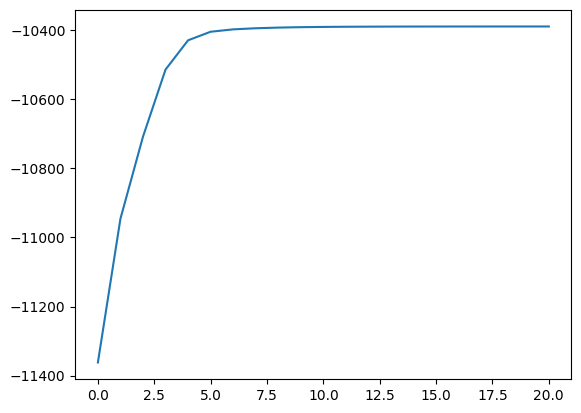

In [5]:
model.fit(ys, frozen=frozen_params)
plt.plot(model.ll_fits)

### Results

Parameters

In [6]:
mu = model.emission.mu(0, ys)
std = model.emission.sigma(0, ys)
transition_matrix = model.transition.transition_matrix(0, ys) 

print("Mu:", mu)
print("----------")
print("Std:", std)
print("----------")
print("Transition matrix:")
for row in transition_matrix:
    print(" ".join(f"{float(v):.2f}" for v in row))

Mu: [ 400.          535.68424024  889.92839567 1306.48367045]
----------
Std: [ 21.74820467  76.5733242  110.98081154 197.4100268 ]
----------
Transition matrix:
0.85 0.15 0.00 0.00
0.08 0.85 0.07 0.00
0.00 0.16 0.68 0.15
0.00 0.00 0.07 0.93


Pseudo Residuals

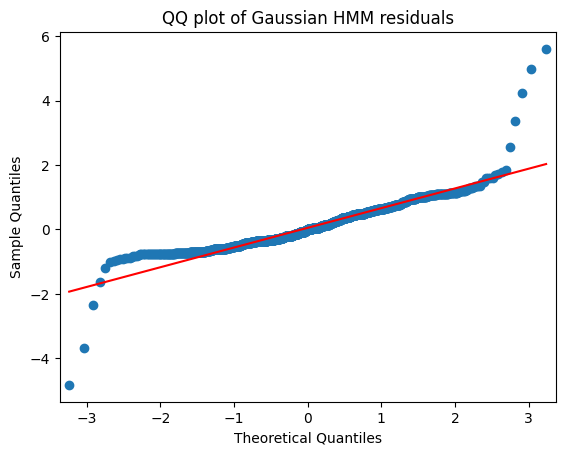

In [7]:
model_results = model.hmm_results 
state_ressults = model.state_results 

results["Gaussian_HMM"] = (model_results, state_ressults, model.params)

sm.qqplot(state_ressults.pseudo_residuals, line='s')
plt.title("QQ plot of Gaussian HMM residuals")
plt.show()

State trajectories

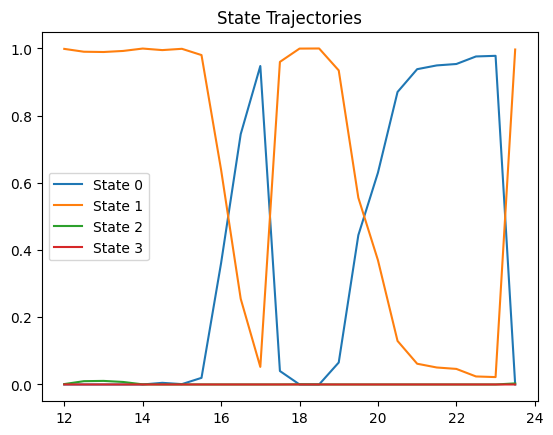

In [8]:

utt = jnp.asarray(state_ressults.utt)
for state in range(utt.shape[1]):
    plt.plot(hour[:HOURS_TO_PLOT], utt[:HOURS_TO_PLOT, state], label=f"State {state}")
plt.legend()
plt.title("State Trajectories")
plt.show()

## Autoregressive HMM of Order 1

### Params config and initialization

In [9]:
from src.api.v4 import AutoregressiveGaussEmission 

phi_vals = jnp.array([0.20, 0.20, 0.20, 0.20])
emission = AutoregressiveGaussEmission.from_params(mu=mu, sigma=std, phi=phi_vals)
tranision = StaticTransition.from_params(transition_matrix)


model = HMM(transition=tranision, emission=emission)


### Fit

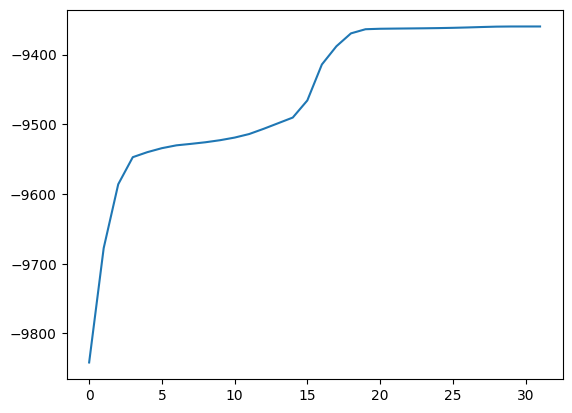

In [10]:
model.fit(ys, frozen=frozen_params)
plt.plot(model.ll_fits)

### Results

Parameters

In [11]:
mu = model.emission.mu(0, ys)
std = model.emission.sigma(0, ys)
transition_matrix = model.transition.transition_matrix(0, ys) 
phi_vals = model.emission.phi()

print("Mu:", mu)
print("----------")
print("Std:", std)
print("----------")
print("Phi:", phi_vals)
print("----------")

print("Transition matrix:")
for row in transition_matrix:
    print(" ".join(f"{float(v):.2f}" for v in row))

Mu: [ 400.          509.32605967  560.28528493 1366.66115665]
----------
Std: [ 12.50081215  77.70427783  11.00587523 102.83581976]
----------
Phi: [[0.62346209 0.36588483 0.94617407 0.83180869]]
----------
Transition matrix:
0.75 0.17 0.00 0.08
0.27 0.60 0.06 0.07
0.05 0.10 0.85 0.00
0.01 0.05 0.02 0.93


Pseudo Residuals

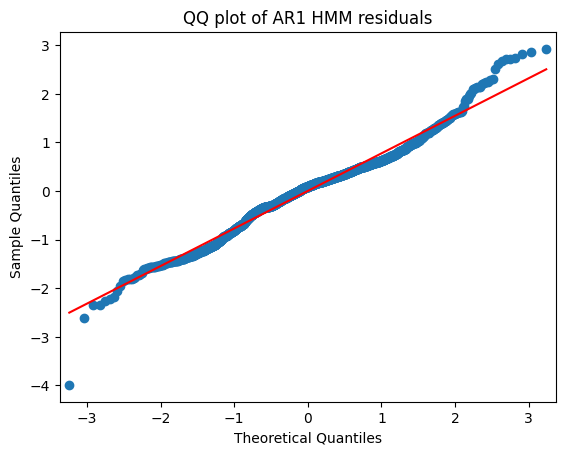

In [12]:
model_results = model.hmm_results 
state_ressults = model.state_results 

results["AR_HMM_Order_1"] = (model_results, state_ressults, model.params)

sm.qqplot(state_ressults.pseudo_residuals, line='s')
plt.title("QQ plot of AR1 HMM residuals")
plt.show()

State trajectories

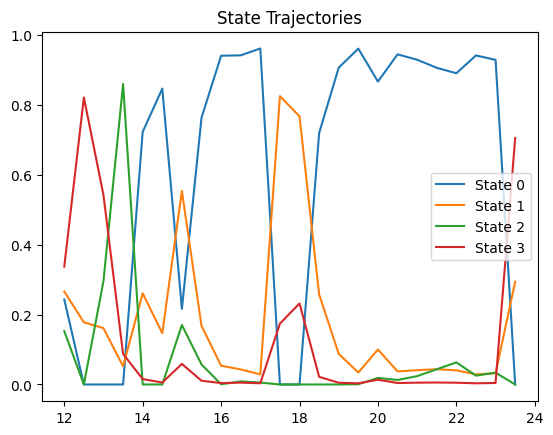

In [13]:
utt = jnp.asarray(state_ressults.utt)
for state in range(utt.shape[1]):
    plt.plot(hour[:HOURS_TO_PLOT], utt[:HOURS_TO_PLOT, state], label=f"State {state}")
plt.legend()
plt.title("State Trajectories")
plt.show()

## Autoregressive HMM of Order 2

### Params config and initialization

In [14]:

phi_vals = jnp.concatenate([phi_vals, jnp.array([[0.20, 0.20, 0.20, 0.20]]) ])

emission = AutoregressiveGaussEmission.from_params(mu=mu, sigma=std, phi=phi_vals)
tranision = StaticTransition.from_params(transition_matrix)


model = HMM(transition=tranision, emission=emission)


### Fit

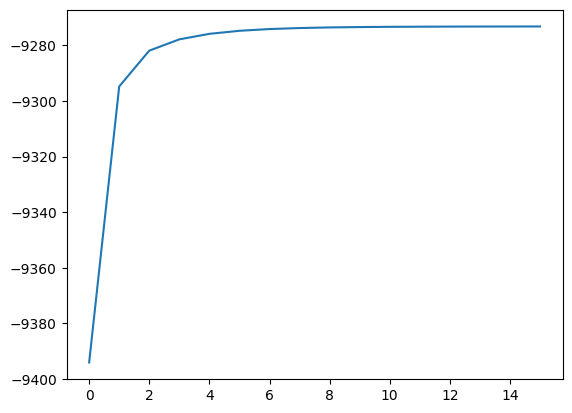

In [15]:
model.fit(ys, frozen=frozen_params)
plt.plot(model.ll_fits)

### Results

Parameters

In [16]:
mu = model.emission.mu(0, ys)
std = model.emission.sigma(0, ys)
transition_matrix = model.transition.transition_matrix(0, ys) 
phi_vals = model.emission.phi()

print("Mu:", mu)
print("----------")
print("Std:", std)
print("----------")
print("Phi:")
for row in phi_vals:
    print(" ".join(f"{float(v):.4f}" for v in row))
print("Row sums:", jnp.sum(phi_vals, axis=0))
print("----------")

print("Transition matrix:")
for row in transition_matrix:
    print(" ".join(f"{float(v):.2f}" for v in row))

Mu: [ 400.          525.63029186  716.01539704 1299.66016981]
----------
Std: [10.76541562 72.08271741 16.15771356 97.60313377]
----------
Phi:
0.7027 0.5941 0.9596 0.9997
-0.0781 -0.2109 0.0565 -0.2093
Row sums: [0.62465727 0.38324201 1.0160753  0.79039244]
----------
Transition matrix:
0.71 0.21 0.00 0.08
0.28 0.55 0.11 0.06
0.02 0.13 0.85 0.00
0.01 0.05 0.02 0.93


Pseudo Residuals

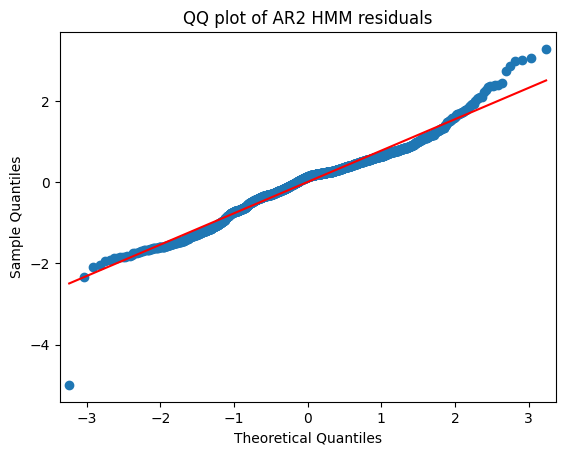

In [17]:
model_results = model.hmm_results 
state_ressults = model.state_results 

results["AR_HMM_Order_2"] = (model_results, state_ressults, model.params)

sm.qqplot(state_ressults.pseudo_residuals, line='s')
plt.title("QQ plot of AR2 HMM residuals")
plt.show()

State trajectories

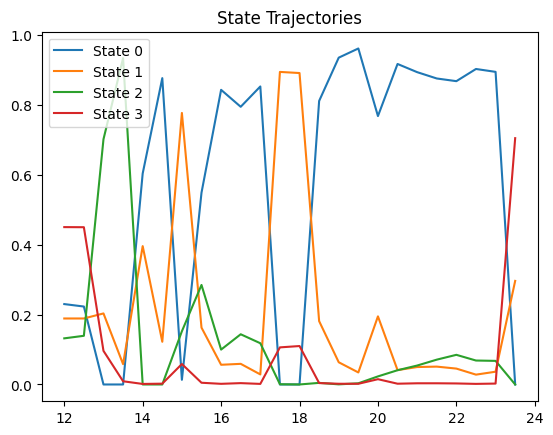

In [18]:
utt = jnp.asarray(state_ressults.utt)
for state in range(utt.shape[1]):
    plt.plot(hour[:HOURS_TO_PLOT], utt[:HOURS_TO_PLOT, state], label=f"State {state}")
plt.legend()
plt.title("State Trajectories")
plt.show()

## Second order Markov HMM

### Params config and initialization

In [19]:
params = results["AR_HMM_Order_2"][2]


In [20]:
from src.api.v4 import StaticTransitionHigherOrder


emission = GaussEmission.from_params(mu=jnp.sort(jnp.repeat(params.emission.mu(0, ys), 4)), sigma=jnp.sort(jnp.repeat(params.emission.sigma(0, ys), 4)))

transition_logits = list(params.transition.transition_logits)

transition = StaticTransitionHigherOrder(jnp.asarray(transition_logits * 4), order=2)

model = HMM(transition=transition, emission=emission)

### Fit

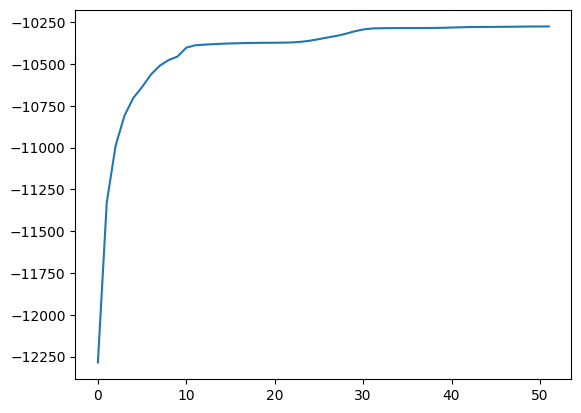

In [21]:
model.fit(ys, frozen=frozen_params)
plt.plot(model.ll_fits)

### Results

Parameters

In [22]:
mu = model.emission.mu(0, ys)
std = model.emission.sigma(0, ys)
transition_matrix = model.transition.transition_matrix(0, ys) 
state_transions = decode_possible_transitions(transition_matrix, order = 2 )

print("Mu:", mu)
print("----------")
print("Std:", std)
print("----------")

#print("Transition matrix:")
#for row in transition_matrix:
#    print(" ".join(f"{float(v):.2f}" for v in row)) 

for state, transition_list in state_transions.items():
    print(f"From {state}:")
    for to_state, prob in transition_list:
        print(f"  To {to_state}: {prob:.2f}") 
    print("----------")

Mu: [ 400.          400.          400.          400.          443.14794364
  443.14794364  443.14794364  443.14794364  582.05566232  582.05566232
  582.05566232  582.05566232 1197.12970804 1197.12970804 1197.12970804
 1197.12970804]
----------
Std: [   6.3774065     5.71040185    6.94347424 1881.52506809   22.54464106
   25.81197789  151.38968004  270.68332659  117.3600851    76.08127526
   62.64249852  227.90562058 1072.05027186  418.21443382  391.61345506
  200.23439376]
----------
From (0, 0):
  To (0, 0): 0.72
  To (0, 1): 0.21
  To (0, 2): 0.07
  To (0, 3): 0.00
----------
From (0, 1):
  To (1, 1): 1.00
----------
From (0, 2):
  To (2, 1): 0.32
  To (2, 2): 0.68
  To (2, 3): 0.00
----------
From (0, 3):
  To (3, 0): 0.80
  To (3, 3): 0.20
----------
From (1, 0):
  To (0, 0): 1.00
----------
From (1, 1):
  To (1, 0): 0.07
  To (1, 1): 0.79
  To (1, 2): 0.11
  To (1, 3): 0.03
----------
From (1, 2):
  To (2, 1): 0.00
  To (2, 2): 0.93
  To (2, 3): 0.07
----------
From (1, 3):
  To (

Pseudo Residuals

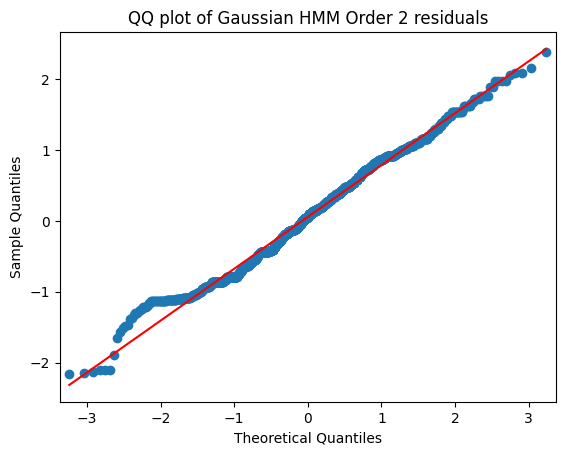

In [23]:
model_results = model.hmm_results 
state_ressults = model.state_results 

results["HMM_Order_2"] = (model_results, state_ressults, model.params)

sm.qqplot(state_ressults.pseudo_residuals, line='s')
plt.title("QQ plot of Gaussian HMM Order 2 residuals")
plt.show()

State trajectories

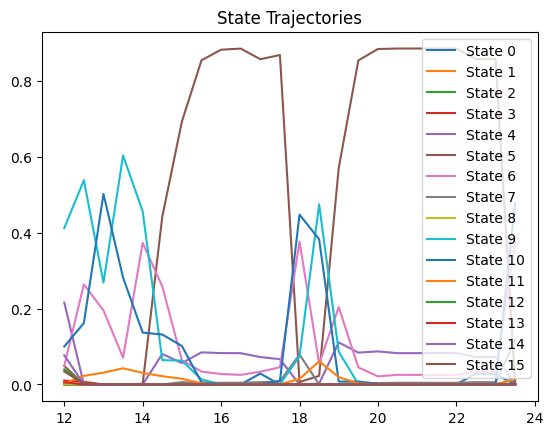

In [24]:
utt = jnp.asarray(state_ressults.utt)
for state in range(utt.shape[1]):
    plt.plot(hour[:HOURS_TO_PLOT], utt[:HOURS_TO_PLOT, state], label=f"State {state}")
plt.legend()
plt.title("State Trajectories")
plt.show()

In [25]:
model_results

HMMResults(convergence=True, log_likelihood=-10274.986791606063, num_params=80)

## Autoregressive HMM of Order 2 with static transition probabilities

### Params config and initialization

In [26]:
phi_vals = results["AR_HMM_Order_2"][2].emission.phi()
phi_vals = jnp.repeat(phi_vals, 4, axis=1)

emission = AutoregressiveGaussEmission.from_params(mu=mu, sigma=std, phi=phi_vals) 
transition = results["HMM_Order_2"][2].transition 
model = HMM(transition=transition, emission=emission)

### Fit

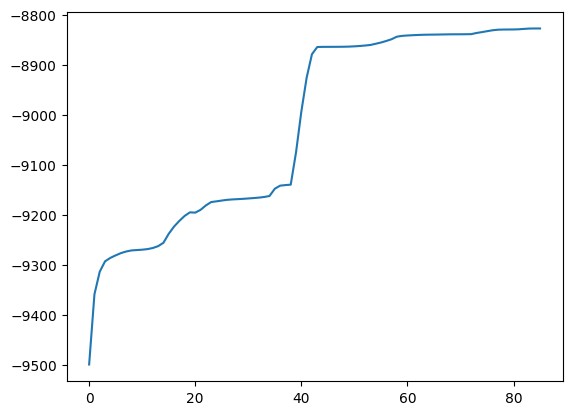

In [27]:
model.fit(ys, frozen=frozen_params)
plt.plot(model.ll_fits)

### Results

Parameters

In [28]:
mu = model.emission.mu(0, ys)
std = model.emission.sigma(0, ys)
transition_matrix = model.transition.transition_matrix(0, ys) 
state_transions = decode_possible_transitions(transition_matrix, order = 2 )

print("Mu:", mu)
print("----------")
print("Std:", std)
print("----------")

#print("Transition matrix:")
#for row in transition_matrix:
#    print(" ".join(f"{float(v):.2f}" for v in row))


for state, transition_list in state_transions.items():
    print(f"From {state}:")
    for to_state, prob in transition_list:
        print(f"  To {to_state}: {prob:.2f}") 
    print("----------")

Mu: [ 400.          400.          400.          400.          513.29488484
  513.29488484  513.29488484  513.29488484  656.66144561  656.66144561
  656.66144561  656.66144561 1456.3929127  1456.3929127  1456.3929127
 1456.3929127 ]
----------
Std: [1.62838991e+01 2.28741557e-01 9.24062579e+00 1.44880325e+02
 3.93728735e+01 8.13729929e+01 2.20950566e+01 4.54886506e+01
 6.00299796e-03 2.55948460e+01 4.14050280e-01 1.02945602e+02
 1.30238828e+02 1.08630084e+02 1.60414599e+02 4.77018363e+01]
----------
From (0, 0):
  To (0, 0): 0.23
  To (0, 1): 0.05
  To (0, 2): 0.71
  To (0, 3): 0.00
----------
From (0, 1):
  To (1, 0): 0.30
  To (1, 1): 0.49
  To (1, 3): 0.21
----------
From (0, 2):
  To (2, 1): 0.36
  To (2, 2): 0.34
  To (2, 3): 0.31
----------
From (0, 3):
  To (3, 0): 0.25
  To (3, 1): 0.17
  To (3, 2): 0.05
  To (3, 3): 0.53
----------
From (1, 0):
  To (0, 0): 1.00
----------
From (1, 1):
  To (1, 0): 0.30
  To (1, 1): 0.48
  To (1, 2): 0.14
  To (1, 3): 0.08
----------
From (1, 2

Pseudo Residuals

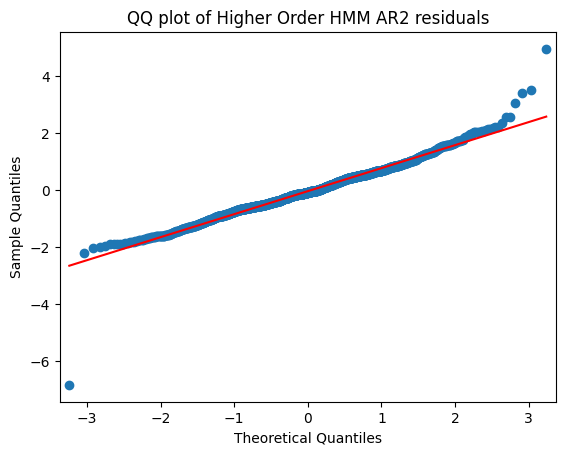

In [29]:
model_results = model.hmm_results 
state_ressults = model.state_results 

results["HMM_AR_Order_2"] = (model_results, state_ressults, model.params)

sm.qqplot(state_ressults.pseudo_residuals, line='s')
plt.title("QQ plot of Higher Order HMM AR2 residuals")
plt.show()

State trajectories

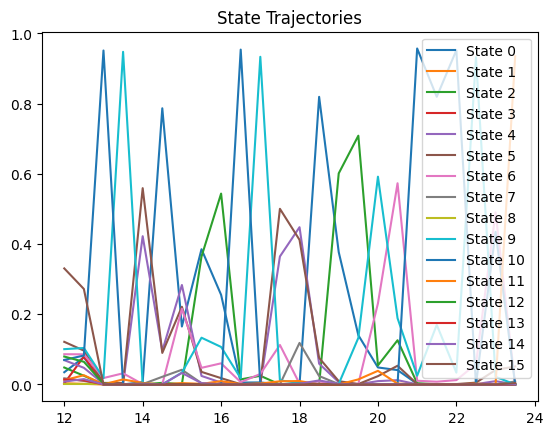

In [30]:
utt = jnp.asarray(state_ressults.utt)
for state in range(utt.shape[1]):
    plt.plot(hour[:HOURS_TO_PLOT], utt[:HOURS_TO_PLOT, state], label=f"State {state}")
plt.legend()
plt.title("State Trajectories")
plt.show()

# Model Comparison

In [31]:
print("Models fitted: {}".format(len(results)))
print("Model names:") 
for name in results.keys():
    print("- {}".format(name))

Models fitted: 5
Model names:
- Gaussian_HMM
- AR_HMM_Order_1
- AR_HMM_Order_2
- HMM_Order_2
- HMM_AR_Order_2


## AIC and BIC comparison

In [ ]:
import pandas as pd 
from src.api.v4.hmm_models.utils import AIC, BIC, LRT

comparison_df = pd.DataFrame(columns=["Model", "Log-Likelihood", "Num Params", "AIC", "BIC"])
num_data_points = len(ys)
for name, (hmm_results, _, _) in results.items():
    aic = AIC(hmm_results)
    bic = BIC(hmm_results, num_data_points)
    df = pd.DataFrame({
        "Model": [name],
        "Log-Likelihood": [hmm_results.log_likelihood],
        "Num Params": [hmm_results.num_params],
        "AIC": [aic],
        "BIC": [bic]
    })
    comparison_df = pd.concat([comparison_df, df], ignore_index=True) 

comparison_df = comparison_df.sort_values(by="AIC")
display(comparison_df)

            Model Log-Likelihood Num Params           AIC           BIC
4  HMM_AR_Order_2   -8827.151729        112  17878.303459  18485.139711
2  AR_HMM_Order_2     -9273.1912         28  18602.382399  18754.091462
1  AR_HMM_Order_1   -9359.726801         24  18767.453601  18897.489941
3     HMM_Order_2  -10274.986792         80  20709.973583  21143.428049
0    Gaussian_HMM  -10388.866738         20  20817.733476  20926.097093


## LRT between nested models

In [33]:
lrt_df = pd.DataFrame(columns=["Base Model", "Expanded Model", "LRT Statistic", "p-value"])

### Gauss HMM vs AR HMM Order 1

In [34]:
#Gauss HMM vs AR HMM Order 1


print("LRT between Gaussian HMM and AR HMM Order 1:")
lrt_statistic, p_value = LRT(results["Gaussian_HMM"][0], results["AR_HMM_Order_1"][0])
print(f"LRT Statistic: {lrt_statistic:.4f}, p-value: {p_value:.4f}") 

df = pd.DataFrame({
    "Base Model": ["Gaussian HMM"],
    "Expanded Model": ["AR HMM Order 1"],
    "LRT Statistic": [lrt_statistic],
    "p-value": [p_value]
})

lrt_df = pd.concat([lrt_df, df], ignore_index=True)

LRT between Gaussian HMM and AR HMM Order 1:
LRT Statistic: 2058.2799, p-value: 0.0000


### AR HMM Order 1 vs AR HMM Order 2

In [35]:

print("LRT between AR HMM Order 1 and AR HMM Order 2:")
lrt_statistic, p_value = LRT(results["AR_HMM_Order_1"][0], results["AR_HMM_Order_2"][0])
print(f"LRT Statistic: {lrt_statistic:.4f}, p-value: {p_value:.4f}") 

df = pd.DataFrame({
    "Base Model": ["AR HMM Order 1"],
    "Expanded Model": ["AR HMM Order 2"],
    "LRT Statistic": [lrt_statistic],
    "p-value": [p_value]
})
lrt_df = pd.concat([lrt_df, df], ignore_index=True)

LRT between AR HMM Order 1 and AR HMM Order 2:
LRT Statistic: 173.0712, p-value: 0.0000


### Order 2 Markov HMM vs AR HMM Order 2 with static transition probabilities

In [36]:
#AR HMM Order 1 vs AR HMM Order 2
print("LRT between HMM Order 2 and AR HMM Order 2:")
lrt_statistic, p_value = LRT(results["HMM_Order_2"][0], results["HMM_AR_Order_2"][0])
print(f"LRT Statistic: {lrt_statistic:.4f}, p-value: {p_value:.4f}") 

df = pd.DataFrame({
    "Base Model": ["HMM Order 2"],
    "Expanded Model": ["HMM AR HMM Order 2"],
    "LRT Statistic": [lrt_statistic],
    "p-value": [p_value]
})
lrt_df = pd.concat([lrt_df, df], ignore_index=True)

LRT between HMM Order 2 and AR HMM Order 2:
LRT Statistic: 2895.6701, p-value: 0.0000


In [37]:
lrt_df 

,Base Model,Expanded Model,LRT Statistic,p-value
0,Gaussian HMM,AR HMM Order 1,2058.279875,0.0
1,AR HMM Order 1,AR HMM Order 2,173.071202,0.0
2,HMM Order 2,HMM AR HMM Order 2,2895.670125,0.0
